In [ ]:
# ============================================
# SECCIÓN 4. PCA - SELECCIÓN DE COMPONENTES
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display, Markdown

# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# --------------------------------------------
# 1. Carga del dataset
# --------------------------------------------
df = sns.load_dataset("penguins").copy()

# --------------------------------------------
# 1. Selección de variables numéricas
# --------------------------------------------
vars_numericas = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

df_num = df[vars_numericas].dropna().copy()

In [3]:
# --------------------------------------------
# 2. Estandarización de variables
# --------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

In [4]:
# --------------------------------------------
# 3. Aplicación de PCA (máximo 4 componentes)
# --------------------------------------------
pca = PCA(n_components=4)
pca.fit(X_scaled)

,n_components,4
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [5]:
# --------------------------------------------
# 4. Varianza explicada
# --------------------------------------------
explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance_cum = np.cumsum(explained_variance_ratio)

# Tabla resumen
pca_summary = pd.DataFrame({
    "Componente": [f"CP{i+1}" for i in range(len(explained_variance))],
    "Autovalor": explained_variance,
    "Varianza explicada": explained_variance_ratio,
    "Varianza acumulada": explained_variance_cum
})

print("Resumen PCA:")
display(pca_summary)

Resumen PCA:


,Componente,Autovalor,Varianza explicada,Varianza acumulada
0,CP1,2.76,0.69,0.69
1,CP2,0.77,0.19,0.88
2,CP3,0.37,0.09,0.97
3,CP4,0.11,0.03,1.00


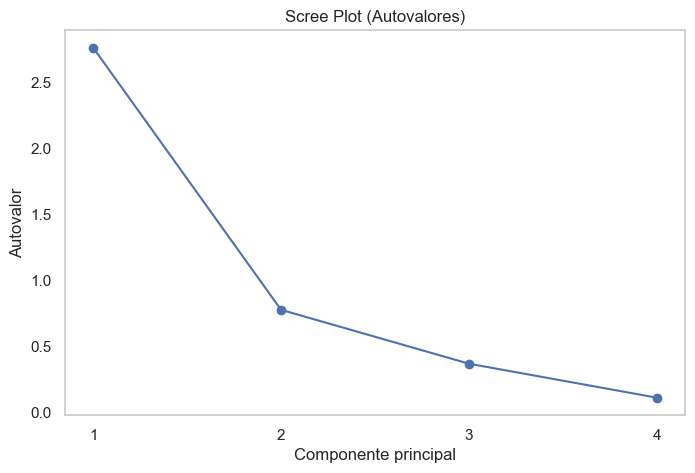

In [6]:
# --------------------------------------------
# 5. Scree Plot (gráfico de sedimentación)
# --------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)

plt.title("Scree Plot (Autovalores)")
plt.xlabel("Componente principal")
plt.ylabel("Autovalor")
plt.xticks(range(1, len(explained_variance) + 1))

plt.grid()
plt.show()

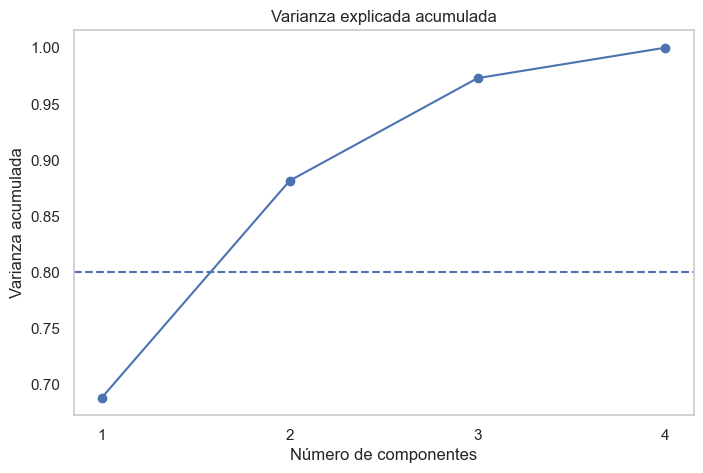

In [7]:
# --------------------------------------------
# 6. Varianza explicada acumulada
# --------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance_cum) + 1),
    explained_variance_cum,
    marker='o'
)

plt.axhline(y=0.8, linestyle='--')  # umbral típico 80%

plt.title("Varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.xticks(range(1, len(explained_variance_cum) + 1))

plt.grid()
plt.show()


In [8]:
# --------------------------------------------
# 7. Componentes principales (cargas)
# --------------------------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"CP{i+1}" for i in range(pca.n_components_)],
    index=vars_numericas
)

print("Cargas de las componentes:")
display(loadings)

Cargas de las componentes:


,CP1,CP2,CP3,CP4
bill_length_mm,0.46,0.60,0.64,-0.15
bill_depth_mm,-0.40,0.80,-0.42,0.17
flipper_length_mm,0.58,0.00,-0.23,0.78
body_mass_g,0.55,0.08,-0.60,-0.58
